In [1]:
import numpy as np
import matplotlib.pyplot as plt
from rfmodel.core.config import load_yaml
from rfmodel.core.signal import Signal
from rfmodel.core.pipeline_builder import pipeline_from_config
from rfmodel.meas.spectrum_analyser import spectrum_analyser
import rfmodel.rf.registry

cfg = load_yaml(r".\PLL_mixer.yaml")
pipe = pipeline_from_config(cfg)


In [2]:
mixer = pipe.get("mixer_and_pll")

# runtime control
mixer.params.mixer_ideal = True
mixer.params.pll.enable_ofdm_weighting = False

In [3]:
# --- Signal ---
fs = 10e6
N = 2**14
t = np.arange(N) / fs
f0 = 1e6
x = np.exp(1j * 2*np.pi*f0*t)
sig = Signal(x=x, fs_hz=fs, meta={})

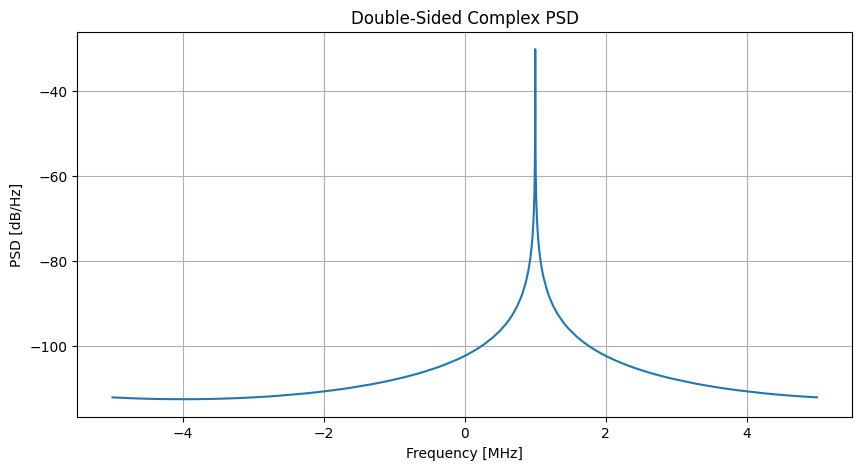

In [ ]:
# --- Process ---
out = mixer.process(sig)

# 1. Keep it complex
y = np.asarray(out.x, dtype=complex).flatten() 
N = len(y)

X = np.fft.fft(y)
f = np.fft.fftfreq(N, 1/fs)

# 3. Shift to center 0 Hz
X_shifted = np.fft.fftshift(X)
f_shifted = np.fft.fftshift(f)

# 4. Calculate PSD
# DO NOT multiply by 2 here. The power is naturally distributed.
PSD = (np.abs(X_shifted)**2) / (fs * N)

# 5. Plotting (Two-sided)
plt.figure(figsize=(10, 5))
plt.plot(f_shifted / 1e6, 10 * np.log10(PSD)) # Freq in MHz for readability
plt.grid(True)
plt.xlabel("Frequency [MHz]")
plt.ylabel("PSD [dB/Hz]")
plt.title("Double-Sided Complex PSD")
plt.show()

In [5]:
carrier_idx = np.argmax(PSD)
f_carrier = f[carrier_idx]
P_carrier_db = 10 * np.log10(PSD[carrier_idx])

offset = 1e6  # 1 MHz
target_freq = f_carrier + offset

idx_offset = np.argmin(np.abs(f - target_freq))
f_carrier

np.float64(-4000244.140625)

In [16]:
window = 5 
P_carrier_total = np.sum(PSD[carrier_idx - window : carrier_idx + window + 1]) * (fs / N)
P_carrier_db = 10 * np.log10(P_carrier_total)

# 2. Find the Noise Density at offset
offset = 1e6 
target_freq = f_carrier + offset
idx_offset = np.argmin(np.abs(f - target_freq))

# This is already a density (dB/Hz), so no integration needed
P_offset_density_db = 10 * np.log10(PSD[idx_offset])

# 3. Final Calculation
phase_noise_1MHz = P_offset_density_db - P_carrier_db
phase_noise_1MHz

np.float64(-102.22593789071473)

In [17]:
P_offset_db = 10 * np.log10(PSD[idx_offset])
phase_noise_1MHz = P_offset_db - P_carrier_db

print(f"Carrier at: {f_carrier/1e6:.2f} MHz")
print(f"Phase Noise at 1MHz offset: {phase_noise_1MHz:.2f} dBc/Hz")

Carrier at: -4.00 MHz
Phase Noise at 1MHz offset: -102.23 dBc/Hz


In [18]:
from scipy import signal

f, psd_smoothed = signal.welch(out.x, fs, nperseg=1024, scaling='density')

carrier_idx = np.argmax(psd_smoothed)
f_carrier = f[carrier_idx]

# 3. Get Carrier Power (Integrate the main lobe)
# For a pure tone, we sum the power in the bins around the peak
rbw = f[1] - f[0] # Resolution Bandwidth
P_carrier_total = np.sum(psd_smoothed[carrier_idx-2 : carrier_idx+3]) * rbw
P_carrier_db = 10 * np.log10(P_carrier_total)

# 4. Get Noise Density at 1MHz offset
target_f = f_carrier + 1e6
idx_offset = np.argmin(np.abs(f - target_f))
P_noise_density_db = 10 * np.log10(psd_smoothed[idx_offset])

# 5. Result in dBc/Hz
phase_noise = P_noise_density_db - P_carrier_db
print(f"Phase Noise: {phase_noise:.2f} dBc/Hz")

Phase Noise: -168.04 dBc/Hz


c:\Users\phill\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:652: UserWarning: Input data is complex, switching to return_onesided=False
  freqs, Pxx = csd(x, x, fs=fs, window=window, nperseg=nperseg,
